# Text Analytics Coursework

This notebook provides some example code for loading and examining the dataset for task 1. 

In [1]:
%load_ext autoreload
%autoreload 2

# Use HuggingFace's datasets library to access the Emotion dataset
from datasets import load_dataset
import numpy as np
import pandas as pd

C:\Users\ZengChunrun\.conda\envs\program\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Task 1 - PubMedQA

Steps:
* Import the dataset
* Medical QA pipeline: baseline system
* Evaluation -- some simple metrics as an example; a naive baseline as input to the example

In [2]:
# Load PubMedQA (the main labeled split is "pqa_labeled"). 
# The other splits are "pqa_unlabeled", which has no yes/no/maybe labels, 
# and "pqa_artificial", which consists of automatically generated 
# questions and answers. 
dataset = load_dataset("pubmed_qa", "pqa_labeled")

# Inspect the dataset
print(dataset)

# Look at the first example
print(dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['pubid', 'question', 'context', 'long_answer', 'final_decision'],
        num_rows: 1000
    })
})
{'pubid': 21645374, 'question': 'Do mitochondria play a role in remodelling lace plant leaves during programmed cell death?', 'context': {'contexts': ['Programmed cell death (PCD) is the regulated death of cells within an organism. The lace plant (Aponogeton madagascariensis) produces perforations in its leaves through PCD. The leaves of the plant consist of a latticework of longitudinal and transverse veins enclosing areoles. PCD occurs in the cells at the center of these areoles and progresses outwards, stopping approximately five cells from the vasculature. The role of mitochondria during PCD has been recognized in animals; however, it has been less studied during PCD in plants.', 'The following paper elucidates the role of mitochondrial dynamics during developmentally regulated PCD in vivo in A. madagascariensis. A single areole wi

To access the important fields:

In [3]:
example = dataset["train"][0]

question = example["question"]
context_paragraphs = example["context"]["contexts"]
label = example["final_decision"]

print("Question:", question)
print("Label:", label)
print("What is inside the context? These are the keys to the context dictionary:", list(example["context"].keys()))
print("The 'context' is an abstract that has been split into paragraphs. \n First context paragraph:", context_paragraphs[0])

Question: Do mitochondria play a role in remodelling lace plant leaves during programmed cell death?
Label: yes
What is inside the context? These are the keys to the context dictionary: ['contexts', 'labels', 'meshes', 'reasoning_required_pred', 'reasoning_free_pred']
The 'context' is an abstract that has been split into paragraphs. 
 First context paragraph: Programmed cell death (PCD) is the regulated death of cells within an organism. The lace plant (Aponogeton madagascariensis) produces perforations in its leaves through PCD. The leaves of the plant consist of a latticework of longitudinal and transverse veins enclosing areoles. PCD occurs in the cells at the center of these areoles and progresses outwards, stopping approximately five cells from the vasculature. The role of mitochondria during PCD has been recognized in animals; however, it has been less studied during PCD in plants.


Combine context paragraphs (common preprocessing step)

In [4]:
def build_context(example):
    example["combined_context"] = " ".join(example["context"]["contexts"])
    return example

dataset = dataset.map(build_context)

print(dataset["train"][0]["combined_context"][:500])

Programmed cell death (PCD) is the regulated death of cells within an organism. The lace plant (Aponogeton madagascariensis) produces perforations in its leaves through PCD. The leaves of the plant consist of a latticework of longitudinal and transverse veins enclosing areoles. PCD occurs in the cells at the center of these areoles and progresses outwards, stopping approximately five cells from the vasculature. The role of mitochondria during PCD has been recognized in animals; however, it has b


The short answers are stored in the field "final_decision" and can take the following values: 

In [5]:
np.unique(dataset["train"]["final_decision"])

array(['maybe', 'no', 'yes'], dtype='<U5')

The long answers look like this and your system could either extract the answer sentences from the context or generate them. Producing long answers is optional.

In [6]:
dataset["train"][0]["long_answer"]

'Results depicted mitochondrial dynamics in vivo as PCD progresses within the lace plant, and highlight the correlation of this organelle with other organelles during developmental PCD. To the best of our knowledge, this is the first report of mitochondria and chloroplasts moving on transvacuolar strands to form a ring structure surrounding the nucleus during developmental PCD. Also, for the first time, we have shown the feasibility for the use of CsA in a whole plant system. Overall, our findings implicate the mitochondria as playing a critical and early role in developmentally regulated PCD in the lace plant.'

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [8]:
df = pd.DataFrame({
    "question": dataset["train"]["question"],
    "context": dataset["train"]["combined_context"],
    "label": dataset["train"]["final_decision"]
})

df["text"] = df["question"].fillna("") + " [SEP] " + df["context"].fillna("")

X_train, X_test, y_train, y_test = train_test_split(
    df["text"],
    df["label"],
    test_size=0.3,
    random_state=42,
    stratify=df["label"]
)

label_order = ["yes", "no", "maybe"]

In [9]:
dt_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(lowercase=True, stop_words="english")),
    ("clf", DecisionTreeClassifier(class_weight="balanced", random_state=42))
])

rf_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(lowercase=True, stop_words="english")),
    ("clf", RandomForestClassifier(
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])

dt_param_grid = {
    "tfidf__max_features": [5000, 10000, 20000],
    "tfidf__ngram_range": [(1, 2), (1, 3)],
    "clf__max_depth": [20, 40, None],
    "clf__min_samples_leaf": [2, 5, 10],
    "clf__criterion": ["gini", "entropy"]
}

rf_param_grid = {
    "tfidf__max_features": [5000, 10000, 20000],
    "tfidf__ngram_range": [(1, 2), (1, 3)],
    "clf__n_estimators": [100, 200, 300],
    "clf__max_depth": [20, 40, 60],
    "clf__min_samples_leaf": [1, 2, 5]
}

In [10]:
dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

In [11]:
dt_grid.fit(X_train, y_train)
rf_grid.fit(X_train, y_train)

best_dt = dt_grid.best_estimator_
best_rf = rf_grid.best_estimator_

print("Best Decision Tree Params:")
print(dt_grid.best_params_)
print("Best Decision Tree CV Macro-F1:", dt_grid.best_score_)

print("\nBest Random Forest Params:")
print(rf_grid.best_params_)
print("Best Random Forest CV Macro-F1:", rf_grid.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best Decision Tree Params:
{'clf__criterion': 'gini', 'clf__max_depth': 40, 'clf__min_samples_leaf': 2, 'tfidf__max_features': 20000, 'tfidf__ngram_range': (1, 3)}
Best Decision Tree CV Macro-F1: 0.3817582628998929

Best Random Forest Params:
{'clf__max_depth': 20, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100, 'tfidf__max_features': 5000, 'tfidf__ngram_range': (1, 3)}
Best Random Forest CV Macro-F1: 0.3714732251951197


In [12]:
models = {
    "Decision Tree": best_dt,
    "Random Forest": best_rf
}

results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    cm = confusion_matrix(y_test, y_pred, labels=label_order)

    results[name] = {"accuracy": acc, "macro_f1": macro_f1, "cm": cm, "y_pred": y_pred}

    print(f"\n=== {name} ===")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro-F1: {macro_f1:.4f}")
    print(classification_report(y_test, y_pred, labels=label_order))



=== Decision Tree ===
Accuracy: 0.4200
Macro-F1: 0.3407
              precision    recall  f1-score   support

         yes       0.57      0.50      0.53       166
          no       0.34      0.38      0.36       101
       maybe       0.11      0.15      0.13        33

    accuracy                           0.42       300
   macro avg       0.34      0.34      0.34       300
weighted avg       0.44      0.42      0.43       300


=== Random Forest ===
Accuracy: 0.5067
Macro-F1: 0.3626
              precision    recall  f1-score   support

         yes       0.58      0.69      0.63       166
          no       0.41      0.35      0.37       101
       maybe       0.13      0.06      0.08        33

    accuracy                           0.51       300
   macro avg       0.37      0.37      0.36       300
weighted avg       0.47      0.51      0.48       300



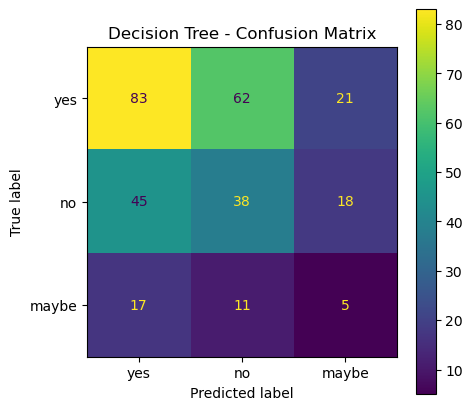

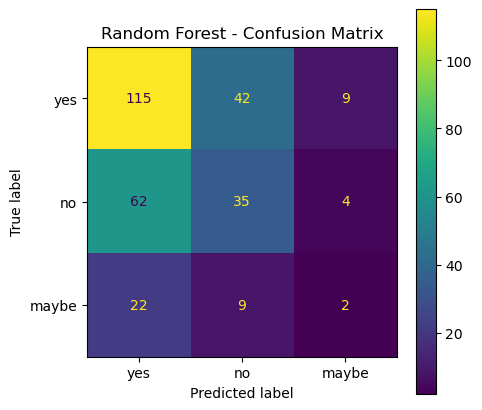

In [13]:
for name, info in results.items():
    fig, ax = plt.subplots(figsize=(5, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=info["cm"], display_labels=label_order)
    disp.plot(ax=ax, values_format="d")
    ax.set_title(f"{name} - Confusion Matrix")
    plt.show()